## 4 Lab

В этой версии следую точно по методичке

Imports:

In [3]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import ccf, adfuller, pacf, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import arma_generate_sample
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
np.random.seed(0)

Загружаем файлы с данными временных рядов ts1 и ts2

In [4]:
response = requests.get("https://zenodo.org/records/10951538/files/arma_ts3.npz?download=1")
response.raise_for_status()
arma_ts1 = np.load(BytesIO(response.content))['signal']
print(len(arma_ts1))

response = requests.get("https://zenodo.org/records/10951538/files/arma_ts4.npz?download=1")
response.raise_for_status()
arma_ts2 = np.load(BytesIO(response.content))['signal']
print(len(arma_ts2))

479
1000


### arma_ts1

1: Разделение на train/test

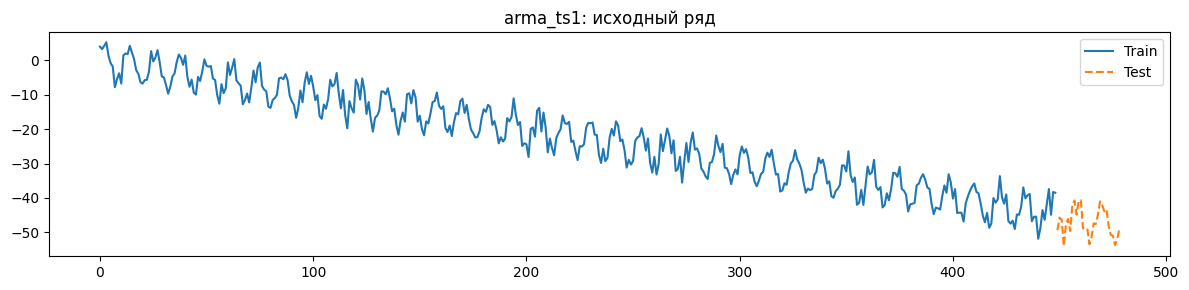

ADF p-value (исходный train1): 0.9329  → НЕ стационарен


In [5]:
train1 = arma_ts1[:-30]
test1  = arma_ts1[-30:]
time1  = np.arange(len(arma_ts1))

_, ax = plt.subplots(figsize=(12, 3))
ax.plot(time1[:len(train1)], train1, label='Train')
ax.plot(time1[len(train1):], test1,  label='Test', linestyle='--')
ax.set_title('arma_ts1: исходный ряд')
ax.legend(); plt.tight_layout(); plt.show()

_, pval, *_ = adfuller(train1)
print(f"ADF p-value (исходный train1): {pval:.4f}  → {'стационарен' if pval < 0.05 else 'НЕ стационарен'}")

на графике чётко видно, что ряд постепенно уходит (нисходящий тренд). горизонтальности нет, значения явно дрейфуют. ADF-тест: (p-value = 0.9329) >>  0.05 - ряд нестационарен (без предобработки строить ARMA напрямую нельзя)

2: Обеспечение стационарности (tes)

Обнаруженный период TS1: 479
Период 479 слишком велик (max=224), используется Holt
ADF: 0.1830  - НЕ стационарны


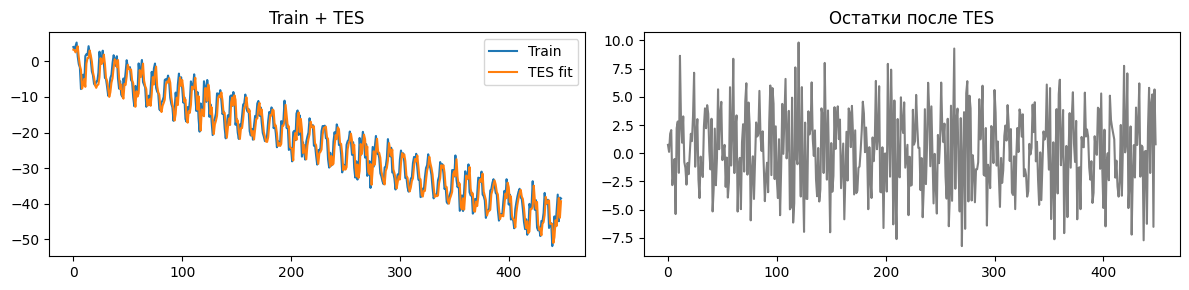

In [30]:
def fft_analysis(signal):
    n = len(signal)
    fft_vals = np.fft.rfft(signal - signal.mean())
    power = np.abs(fft_vals) ** 2
    freqs = np.fft.rfftfreq(n)
    idx = np.argmax(power[1:]) + 1
    dominant_freq = freqs[idx]
    dominant_period = 1.0 / dominant_freq if dominant_freq > 0 else np.inf
    return dominant_period, freqs, power

period1, _, _ = fft_analysis(arma_ts1)
period1 = int(np.round(period1))
print(f"Обнаруженный период TS1: {period1}")

# Период не должен превышать половины train (нужно минимум 2 полных цикла)
max_period1 = len(train1) // 2

if 1 < period1 <= max_period1:
    tes1 = ExponentialSmoothing(train1, trend='add', seasonal='add',
                                seasonal_periods=period1).fit(optimized=True)
else:
    if period1 > max_period1:
        print(f"Период {period1} слишком велик (max={max_period1}), используется Holt")
    tes1 = Holt(train1).fit(optimized=True)

resid1 = train1 - tes1.fittedvalues

_, pval_r, *_ = adfuller(resid1)
print(f"ADF: {pval_r:.4f}  - {'стационарны' if pval_r < 0.05 else 'НЕ стационарны'}")

_, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(train1, label='Train'); axes[0].plot(tes1.fittedvalues, label='TES fit')
axes[0].set_title('Train + TES'); axes[0].legend()
axes[1].plot(resid1, color='gray'); axes[1].set_title('Остатки после TES')
plt.tight_layout(); plt.show()


FFT нашёл доминирующий период 479. Т.к. данных не хватает, используется метод Холта (только тренд, без сезонности). Подгонка получилась хорошая, оранжевая линия TES аккуратно следует за синим рядом. Остатки визуально колеблются около нуля, однако по  ADF p-value=0.1830, получается, что они всё ещё нестационарны. Это означает, что Холт убрал тренд, но какая-то структура (затухающая автокорреляция) ещё осталась

3: Определение порядка p модели AR (по PACF)

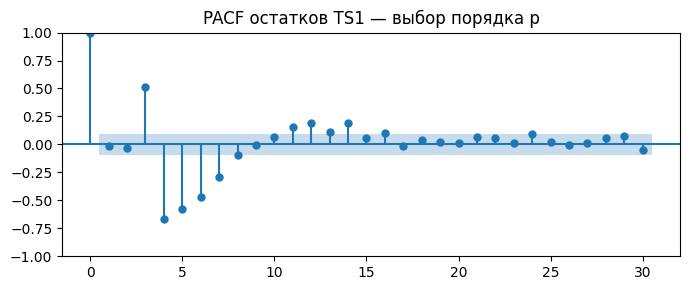

In [21]:
_, ax = plt.subplots(figsize=(7, 3))
plot_pacf(resid1, lags=30, ax=ax, title="PACF остатков TS1 — выбор порядка p")
plt.tight_layout(); plt.show()

выбор p (последний значимый лаг в PACF)

In [22]:
pacf_vals, conf_pacf = pacf(resid1, nlags=30, alpha=0.05)
sig_pacf = np.where(np.abs(pacf_vals[1:]) > (conf_pacf[1:, 1] - pacf_vals[1:]))[0]
p1 = int(sig_pacf[-1]) + 1 if len(sig_pacf) > 0 else 1
print(f"Выбранный порядок AR: p = {p1}")

Выбранный порядок AR: p = 29


на графике видны значимые выбросы за доверительный интервал, они тянутся вплоть до лага 29. Это говорит о том, что каждое значение остатков зависит от p = 29 (далекого прошлого).

4: Прогноз с помощью AR(p)

In [10]:
pacf_vals, conf_pacf = pacf(resid1, nlags=30, alpha=0.05)
sig_pacf = np.where(np.abs(pacf_vals[1:]) > (conf_pacf[1:, 1] - pacf_vals[1:]))[0]
p1 = int(sig_pacf[-1]) + 1 if len(sig_pacf) > 0 else 1
print(f"Выбранный порядок AR: p = {p1}")

Выбранный порядок AR: p = 29


AR(p) на остатках TES

In [11]:
ar_model1 = ARIMA(resid1, order=(p1, 0, 0)).fit()
ar_resid_preds1 = ar_model1.forecast(steps=30)

Восстановление прогноза. TES прогноз и AR прогноз остатков

MSE AR(29) для TS1: 66.5582


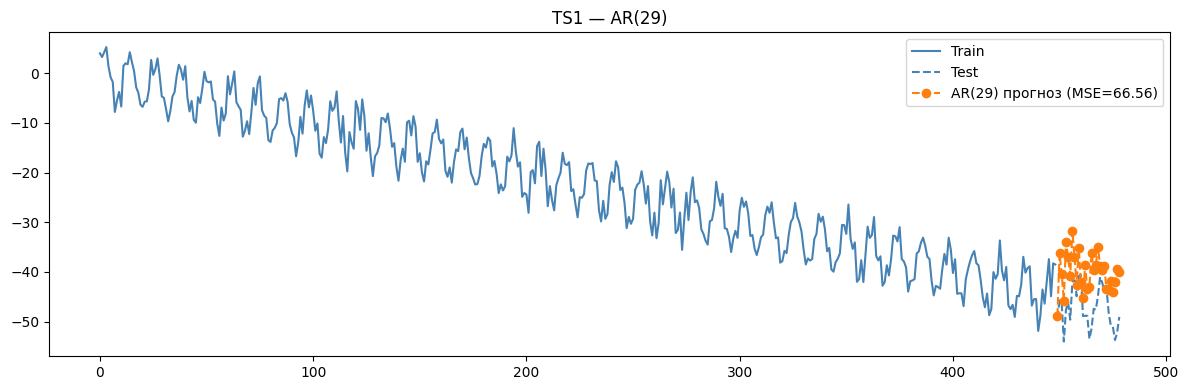

In [12]:
tes_forecast1 = tes1.forecast(30)
ar_preds1 = tes_forecast1 + ar_resid_preds1
mse_ar1 = mean_squared_error(test1, ar_preds1)
print(f"MSE AR({p1}) для TS1: {mse_ar1:.4f}")

_, ax = plt.subplots(figsize=(12, 4))
ax.plot(time1[:len(train1)], train1, label='Train', color='steelblue')
ax.plot(time1[len(train1):], test1,  label='Test',  color='steelblue', linestyle='--')
ax.plot(time1[len(train1):], ar_preds1,
        label=f'AR({p1}) прогноз (MSE={mse_ar1:.2f})',
        color='tab:orange', linestyle='--', marker='o')
ax.set_title(f'TS1 — AR({p1})'); ax.legend(); plt.tight_layout(); plt.show()

модель AR(р=29) в среднем попадает в нужный диапазон значений, но прогноз как будто бы подпрыгнул. MSE=66.56 это довольно большая ошибка, что логично. ТК остатки после Холта ещё не были строго стационарными, и AR вынужден работать с зашумлёнными данными

5: Определение порядка q модели MA (по ACF)

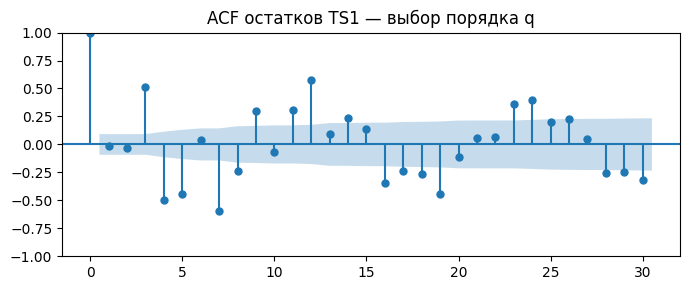

In [13]:
_, ax = plt.subplots(figsize=(7, 3))
plot_acf(resid1, lags=30, ax=ax, title="ACF остатков TS1 — выбор порядка q")
plt.tight_layout(); plt.show()

6: Прогноз с помощью MA(q)
Автоматический выбор q (последний значимый лаг в ACF)

In [14]:
acf_vals, conf_acf = acf(resid1, nlags=30, alpha=0.05)
sig_acf = np.where(np.abs(acf_vals[1:]) > (conf_acf[1:, 1] - acf_vals[1:]))[0]
q1 = int(sig_acf[-1]) + 1 if len(sig_acf) > 0 else 1
print(f"Выбранный порядок MA: q = {q1}")

Выбранный порядок MA: q = 30


ACF показывает значимые корреляции практически на всех 30 лагах (нестационарность). Автоматически выбирается максимальное значение из рассмотренного диапазона. Где-то на этапе обеспечения стационарности ошибка?

 MA(q) на остатках TES

In [15]:
ma_model1 = ARIMA(resid1, order=(0, 0, q1)).fit()
ma_resid_preds1 = ma_model1.forecast(steps=30)

Восстановление прогноза

MSE MA(30) для TS1: 67.8185


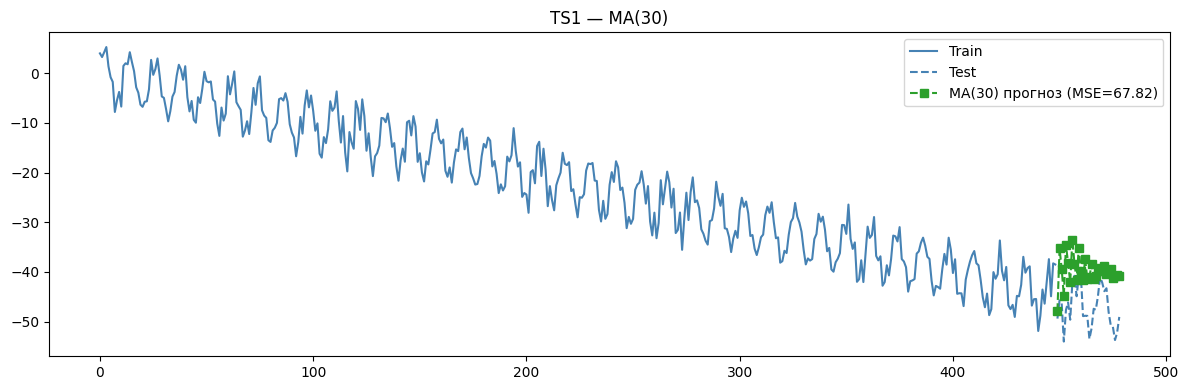

In [16]:
ma_preds1 = tes_forecast1 + ma_resid_preds1
mse_ma1 = mean_squared_error(test1, ma_preds1)
print(f"MSE MA({q1}) для TS1: {mse_ma1:.4f}")

_, ax = plt.subplots(figsize=(12, 4))
ax.plot(time1[:len(train1)], train1, label='Train', color='steelblue')
ax.plot(time1[len(train1):], test1,  label='Test',  color='steelblue', linestyle='--')
ax.plot(time1[len(train1):], ma_preds1,
        label=f'MA({q1}) прогноз (MSE={mse_ma1:.2f})',
        color='tab:green', linestyle='--', marker='s')
ax.set_title(f'TS1 — MA({q1})'); ax.legend(); plt.tight_layout(); plt.show()

MA(30) даёт MSE = 67.82 чуть хуже, чем AR(29) (66.56). Визуально прогнозы  похожи, но МА будет похуже, ьк не захватывает резкие провалы теста

### arma_ts2

1: Разделение на train/test

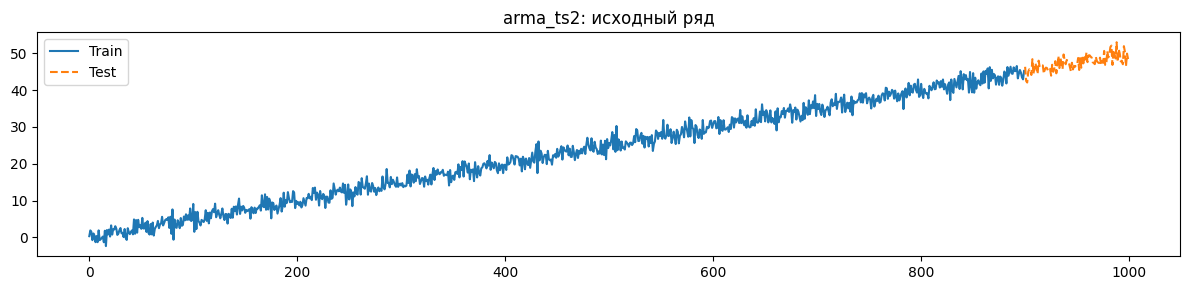

ADF p-value : 0.9471  - НЕ стационарен


In [32]:
train2 = arma_ts2[:-100]
test2  = arma_ts2[-100:]
time2  = np.arange(len(arma_ts2))

_, ax = plt.subplots(figsize=(12, 3))
ax.plot(time2[:len(train2)], train2, label='Train')
ax.plot(time2[len(train2):], test2,  label='Test', linestyle='--')
ax.set_title('arma_ts2: исходный ряд'); ax.legend(); plt.tight_layout(); plt.show()

_, pval2, *_ = adfuller(train2)
print(f"ADF p-value : {pval2:.4f}  - {'стационарен' if pval2 < 0.05 else 'НЕ стационарен'}")

TS2 полная противоположность TS1 по форме. ряд уверенно растёт , тренд восходящий и выраженный. ADF p-value=0.9471  нестационарность ещё очевиднее, чем в TS1

2: Обеспечение стационарности

Обнаруженный период TS2: 1000
Период 1000 слишком велик (max=450), используется Holt
ADF p-value (остатки TES TS2): 0.0000  → стационарны


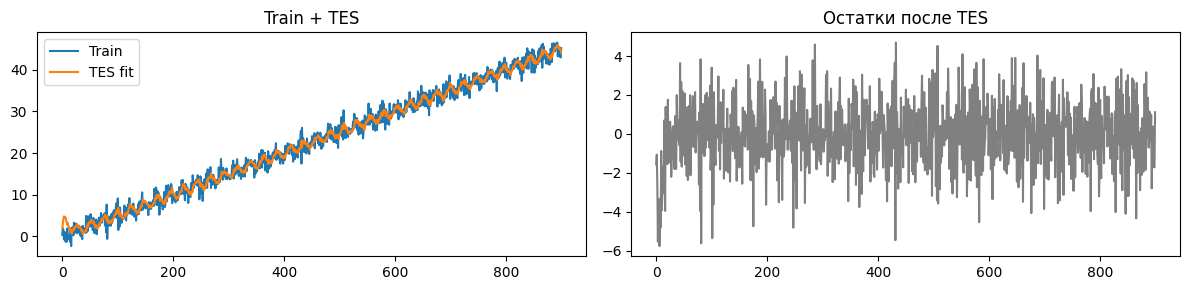

In [28]:
period2, _, _ = fft_analysis(arma_ts2)
period2 = int(np.round(period2))
print(f"Обнаруженный период TS2: {period2}")

# Период не должен превышать половины train (нужно минимум 2 полных цикла)
max_period2 = len(train2) // 2

if 1 < period2 <= max_period2:
    tes2 = ExponentialSmoothing(train2, trend='add', seasonal='add',
                                seasonal_periods=period2).fit(optimized=True)
else:
    if period2 > max_period2:
        print(f"Период {period2} слишком велик (max={max_period2}), используется Holt")
    tes2 = Holt(train2).fit(optimized=True)

resid2 = train2 - tes2.fittedvalues

_, pval_r2, *_ = adfuller(resid2)
print(f"ADF p-value (остатки TES TS2): {pval_r2:.4f}  → {'стационарны' if pval_r2 < 0.05 else 'НЕ стационарны'}")

_, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(train2, label='Train'); axes[0].plot(tes2.fittedvalues, label='TES fit')
axes[0].set_title('Train + TES'); axes[0].legend()
axes[1].plot(resid2, color='gray'); axes[1].set_title('Остатки после TES')
plt.tight_layout(); plt.show()


как и в TS1, FFT ошибочно указал на период весь ряд 1000, снова используется Холт. Однако остатки колеблются строго около нуля (если сравнивать с ts1) без каких либо тенденций, а ADF p-value=0.0000 стационарность достигнута.Получился лучший результат, чем для TS1

3: PACF

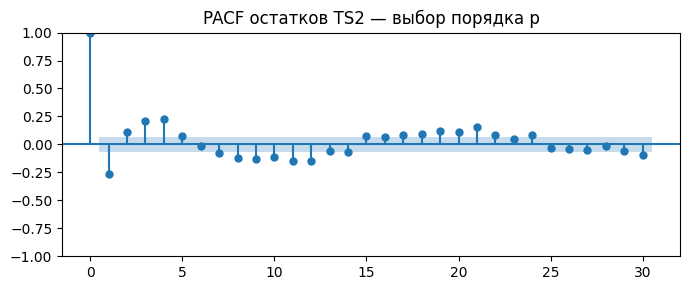

In [24]:
_, ax = plt.subplots(figsize=(7, 3))
plot_pacf(resid2, lags=30, ax=ax, title="PACF остатков TS2 — выбор порядка p")
plt.tight_layout(); plt.show()

PACF остатков TS2 картина получилась чище, чем у TS1. значимых лагов заметно меньше, и они сосредоточены в начале

4: AR прогноз

Выбранный порядок AR: p = 30
MSE AR(30) для TS2: 21.2225


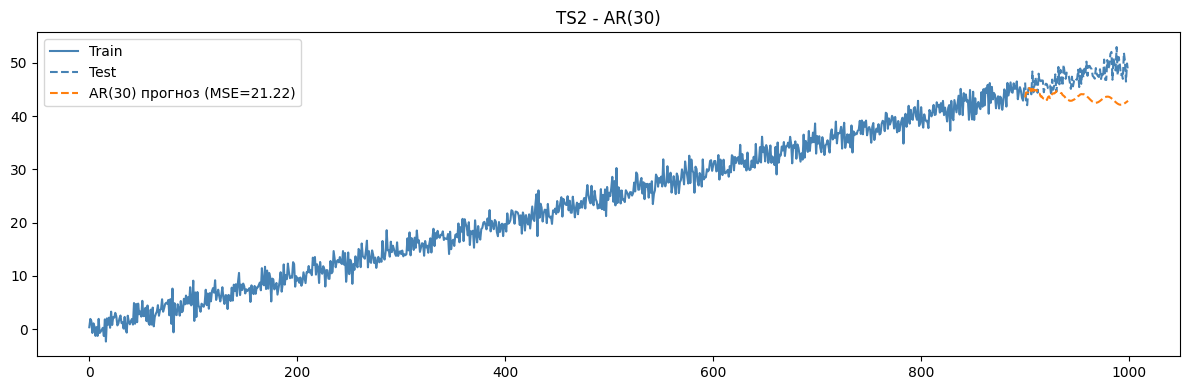

In [33]:
pacf_vals2, conf_pacf2 = pacf(resid2, nlags=30, alpha=0.05)
sig_pacf2 = np.where(np.abs(pacf_vals2[1:]) > (conf_pacf2[1:, 1] - pacf_vals2[1:]))[0]
p2 = int(sig_pacf2[-1]) + 1 if len(sig_pacf2) > 0 else 1
print(f"Выбранный порядок AR: p = {p2}")

ar_model2 = ARIMA(resid2, order=(p2, 0, 0)).fit()
ar_resid_preds2 = ar_model2.forecast(steps=100)

tes_forecast2 = tes2.forecast(100)
ar_preds2 = tes_forecast2 + ar_resid_preds2
mse_ar2 = mean_squared_error(test2, ar_preds2)
print(f"MSE AR({p2}) для TS2: {mse_ar2:.4f}")

_, ax = plt.subplots(figsize=(12, 4))
ax.plot(time2[:len(train2)], train2, label='Train', color='steelblue')
ax.plot(time2[len(train2):], test2,  label='Test',  color='steelblue', linestyle='--')
ax.plot(time2[len(train2):], ar_preds2,
        label=f'AR({p2}) прогноз (MSE={mse_ar2:.2f})',
        color='tab:orange', linestyle='--')
ax.set_title(f'TS2 - AR({p2})'); ax.legend(); plt.tight_layout(); plt.show()

Выбран порядок 30, алгоритм взял последний значимый лаг в пределах окна 30. ARдаёт MSE=21.22, что, чем AR для TS1. следствие качественной предобработки Визуально прогноз держится чуть ниже тестового ряда, но общий уровень и форма схвачены неплохо)

5: ACF тест, определяем порядок q

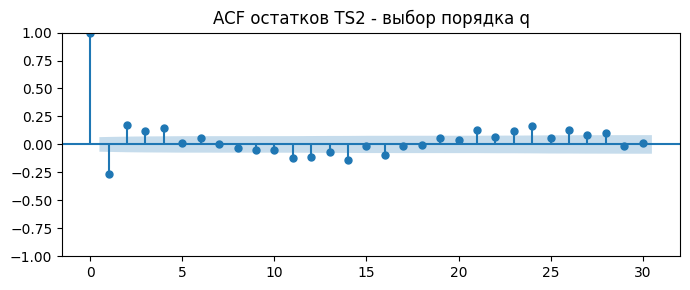

In [34]:
_, ax = plt.subplots(figsize=(7, 3))
plot_acf(resid2, lags=30, ax=ax, title="ACF остатков TS2 - выбор порядка q")
plt.tight_layout(); plt.show()

ACF остатков TS2 также выглядит лучше, значимые корреляции присутствуют, но ближе к 0. (подтверждает стационарность)

6: MA прогноз

Выбранный порядок MA: q = 28


c:\Users\RomanovHome\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


MSE MA(28) для TS2: 21.7623


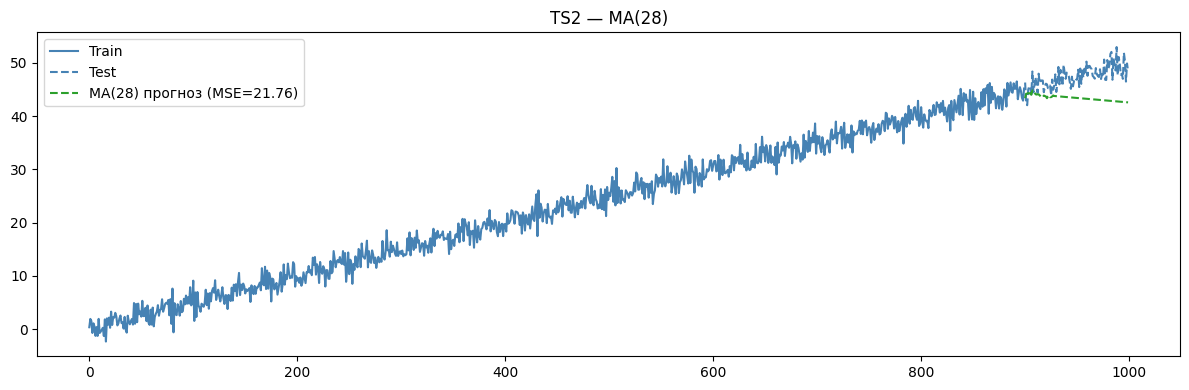

In [27]:
acf_vals2, conf_acf2 = acf(resid2, nlags=30, alpha=0.05)
sig_acf2 = np.where(np.abs(acf_vals2[1:]) > (conf_acf2[1:, 1] - acf_vals2[1:]))[0]
q2 = int(sig_acf2[-1]) + 1 if len(sig_acf2) > 0 else 1
print(f"Выбранный порядок MA: q = {q2}")

ma_model2 = ARIMA(resid2, order=(0, 0, q2)).fit()
ma_resid_preds2 = ma_model2.forecast(steps=100)

ma_preds2 = tes_forecast2 + ma_resid_preds2
mse_ma2 = mean_squared_error(test2, ma_preds2)
print(f"MSE MA({q2}) для TS2: {mse_ma2:.4f}")

_, ax = plt.subplots(figsize=(12, 4))
ax.plot(time2[:len(train2)], train2, label='Train', color='steelblue')
ax.plot(time2[len(train2):], test2,  label='Test',  color='steelblue', linestyle='--')
ax.plot(time2[len(train2):], ma_preds2,
        label=f'MA({q2}) прогноз (MSE={mse_ma2:.2f})',
        color='tab:green', linestyle='--')
ax.set_title(f'TS2 — MA({q2})'); ax.legend(); plt.tight_layout(); plt.show()

MA(28) даёт MSE=21.76, практически вровень с AR(30) (21.22). Разница небольшая, оба метода для TS2 равнозначны. Прогноз визуально монотонно убывает чуть быстрее реального ряда, но начальный уровень угадан верно. На точность не повлияло

качество прогноза сильно зависит от предобработки. Там, где Холт полностью убрал нестационарность (TS2), ошибки в 3 раза меньше. Для TS1 Холт справился лишь частично, и обе модели работают заметно хуже
